# Minimal Inverse Calibration — Recovering Thermal Conductivity

**Problem:** 1-D steady-state heat equation with internal source
$$-k \frac{d^2T}{dx^2} = Q, \quad x \in [0, L]$$
$$T(0) = T_L, \quad T(L) = T_R$$

**Analytical solution:**
$$T(x) = T_L + \frac{T_R - T_L}{L}\,x + \frac{Q}{2k}\,x(L-x)$$

**Inverse task:** given synthetic point measurements generated from the analytical solution
with a known `k_true`, use a FEM forward model + `scipy.optimize` to recover `k`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, minimize
from mpi4py import MPI

from dolfinx import fem, mesh as dmesh
from dolfinx.fem.petsc import LinearProblem
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
import ufl

## 1 — Problem definition

In [2]:
# ── Geometry ─────────────────────────────────────────────────────────────────
L      = 0.1          # rod length [m]
N_elem = 100          # FEM elements

# ── Boundary conditions ───────────────────────────────────────────────────────
T_L = 300.0           # temperature at x=0  [K]
T_R = 320.0           # temperature at x=L  [K]
Q   = 5_000.0         # uniform heat source  [W/m³]

# ── True material parameter (what the optimizer must recover) ─────────────────
k_true = 0.85         # thermal conductivity  [W/(m·K)]

# ── Measurement positions ────────────────────────────────────────────────────
x_meas = np.array([0.01, 0.02, 0.04, 0.05, 0.06, 0.08, 0.09])  # [m]

# ── Analytical solution ───────────────────────────────────────────────────────
def T_analytical(x, k):
    return T_L + (T_R - T_L) / L * x + Q / (2 * k) * x * (L - x)

# Synthetic measurements (analytical + optional noise)
noise_std = 0.0       # set > 0 to test robustness
rng = np.random.default_rng(42)
T_meas = T_analytical(x_meas, k_true) + rng.normal(0, noise_std, len(x_meas))

print(f"True k       : {k_true} W/(m·K)")
print(f"Measurements : {T_meas.round(4)}")

True k       : 0.85 W/(m·K)
Measurements : [304.6471 308.7059 315.0588 317.3529 319.0588 320.7059 320.6471]


## 2 — FEM forward model

In [3]:
def eval_at_points(T_h, msh, x_pts):
    """Evaluate a DOLFINx Function at given x-coordinates (1D)."""
    pts       = np.column_stack([x_pts, np.zeros(len(x_pts)), np.zeros(len(x_pts))])
    tree      = bb_tree(msh, msh.topology.dim)
    cell_cand = compute_collisions_points(tree, pts)
    colliding = compute_colliding_cells(msh, cell_cand, pts)
    # adjacency list — take the first cell found for each point
    cells = colliding.array[colliding.offsets[:-1]]
    return T_h.eval(pts, cells).flatten()


def fem_solve(k: float):
    """Solve -k·T'' = Q on [0,L] with Dirichlet BCs. Returns T evaluated at x_meas."""
    msh = dmesh.create_interval(MPI.COMM_WORLD, N_elem, [0.0, L])
    V   = fem.functionspace(msh, ("Lagrange", 1))

    fdim = msh.topology.dim - 1
    left_facets  = dmesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[0], 0.0))
    right_facets = dmesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[0], L))

    bc_left  = fem.dirichletbc(
        fem.Constant(msh, T_L),
        fem.locate_dofs_topological(V, fdim, left_facets), V)
    bc_right = fem.dirichletbc(
        fem.Constant(msh, T_R),
        fem.locate_dofs_topological(V, fdim, right_facets), V)

    u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
    a    = fem.Constant(msh, k) * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    f    = fem.Constant(msh, Q) * v * ufl.dx

    T_h = LinearProblem(a, f, bcs=[bc_left, bc_right],
                        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
                        petsc_options_prefix="inv_").solve()

    return eval_at_points(T_h, msh, x_meas)


# Sanity check: FEM with k_true should match analytical
T_fem_check = fem_solve(k_true)
T_ana_check = T_analytical(x_meas, k_true)
print("FEM vs analytical max error (should be ~1e-6):")
print(np.abs(T_fem_check - T_ana_check).max())

FEM vs analytical max error (should be ~1e-6):
2.8990143619012088e-12


## 3 — Objective function & optimizer

In [4]:
eval_log = []   # track convergence

def objective(k):
    k = float(k)
    if k <= 0:
        return 1e10
    T_fem = fem_solve(k)
    mse   = np.mean((T_fem - T_meas) ** 2)
    eval_log.append((k, mse))
    return mse

# 1-D bounded search — no gradient needed
result = minimize_scalar(objective, bounds=(0.1, 5.0), method="bounded",
                         options={"xatol": 1e-6})

k_opt = result.x
print(f"k_true : {k_true:.6f} W/(m·K)")
print(f"k_opt  : {k_opt:.6f} W/(m·K)")
print(f"Error  : {abs(k_opt - k_true):.2e} W/(m·K)")
print(f"Evals  : {len(eval_log)}")

k_true : 0.850000 W/(m·K)
k_opt  : 0.850000 W/(m·K)
Error  : 3.43e-09 W/(m·K)
Evals  : 15


## 4 — Results

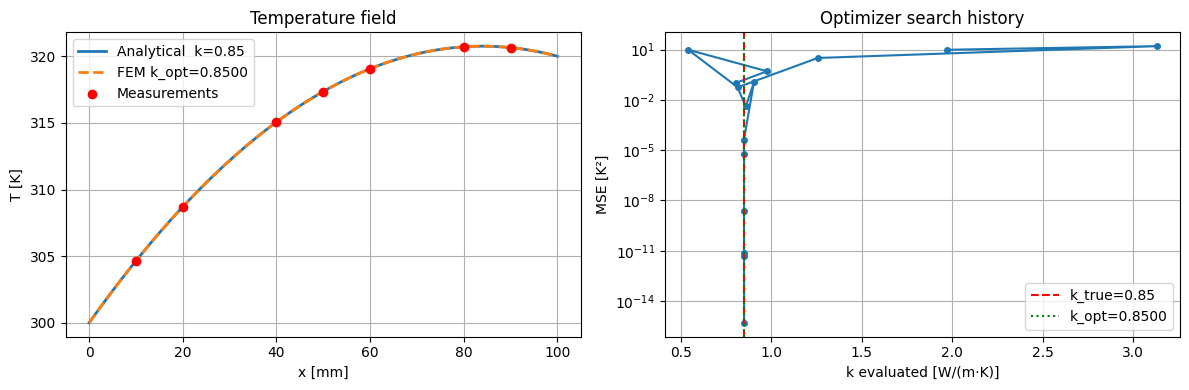

In [5]:
x_plot = np.linspace(0, L, 300)
T_ana  = T_analytical(x_plot, k_true)
T_opt  = T_analytical(x_plot, k_opt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Temperature field
ax = axes[0]
ax.plot(x_plot * 1e3, T_ana,  label=f"Analytical  k={k_true}", lw=2)
ax.plot(x_plot * 1e3, T_opt,  label=f"FEM k_opt={k_opt:.4f}", lw=2, ls="--")
ax.scatter(x_meas * 1e3, T_meas, zorder=5, label="Measurements", color="red")
ax.set_xlabel("x [mm]")
ax.set_ylabel("T [K]")
ax.set_title("Temperature field")
ax.legend()
ax.grid(True)

# Convergence
ax = axes[1]
ks, mses = zip(*eval_log)
ax.semilogy(ks, mses, "o-", ms=4)
ax.axvline(k_true, color="red",  ls="--", label=f"k_true={k_true}")
ax.axvline(k_opt,  color="green", ls=":",  label=f"k_opt={k_opt:.4f}")
ax.set_xlabel("k evaluated [W/(m·K)]")
ax.set_ylabel("MSE [K²]")
ax.set_title("Optimizer search history")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## 5 — Extend: identify multiple parameters

To identify `k` **and** `Q` simultaneously, swap `minimize_scalar` for `minimize`:

In [7]:
def fem_solve_kQ(k: float, Q_val: float):
    msh = dmesh.create_interval(MPI.COMM_WORLD, N_elem, [0.0, L])
    V   = fem.functionspace(msh, ("Lagrange", 1))
    fdim = msh.topology.dim - 1
    bc_left  = fem.dirichletbc(fem.Constant(msh, T_L),
                               fem.locate_dofs_topological(V, fdim,
                               dmesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[0], 0.0))), V)
    bc_right = fem.dirichletbc(fem.Constant(msh, T_R),
                               fem.locate_dofs_topological(V, fdim,
                               dmesh.locate_entities_boundary(msh, fdim, lambda x: np.isclose(x[0], L))), V)
    u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
    a = fem.Constant(msh, k)     * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    f = fem.Constant(msh, Q_val) * v * ufl.dx
    T_h = LinearProblem(a, f, bcs=[bc_left, bc_right],
                        petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
                        petsc_options_prefix="inv2_").solve()
    return eval_at_points(T_h, msh, x_meas)

def objective_2p(params):
    k_val, Q_val = params
    if k_val <= 0 or Q_val <= 0:
        return 1e10
    return float(np.mean((fem_solve_kQ(k_val, Q_val) - T_meas) ** 2))

res2 = minimize(objective_2p, x0=[1.0, 3000.0],
                method="Nelder-Mead",
                options={"xatol": 1e-6, "fatol": 1e-10, "maxiter": 1000})

k_opt2, Q_opt2 = res2.x
print(f"True  : k={k_true}  Q={Q}")
print(f"Found : k={k_opt2:.5f}  Q={Q_opt2:.2f}")
print(f"Error : Δk={abs(k_opt2-k_true):.2e}  ΔQ={abs(Q_opt2-Q):.2e}")

True  : k=0.85  Q=5000.0
Found : k=0.65540  Q=3855.27
Error : Δk=1.95e-01  ΔQ=1.14e+03
